# Positional Encodings in RL4CO

This notebook demonstrates how to *use* and *visualize* every positional encoding (PE) in
[`rl4co/utils/pe.py`](../../rl4co/utils/pe.py). It is organized around the three desiderata
that the survey/method paper uses to characterize PEs for neural combinatorial optimization
(routing in particular):

- **D1 — distance awareness**: the embedding gap between two nodes on the same route should reflect their *physical* separation along the tour, not just their index distance.
- **D2 — circularity**: a route is a cycle (`v_1 = v_L = depot`); the encoding of the two endpoints should coincide, and ideally the encoding should be insensitive to the (arbitrary) traversal direction for symmetric problems.
- **D3 — hierarchy**: two nodes at the same *within-route* index but in *different* routes should be distinguishable; the encoding should carry an across-route (global) signal.

We walk through the PE families in order — index-based / NLP-style, cyclic, attention-bias /
rotation, graph-transformer, and the proposed IPE / XPE / Hierarchical encodings — and for
each one show a small visualization of which desiderata it does (and does not) satisfy.

<a href="https://colab.research.google.com/github/ai4co/rl4co/blob/main/examples/other/4-positional-encodings.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

## Setup and shared toy data

We use two tiny synthetic objects throughout:

1. a **TSP instance + nearest-neighbour tour** (generated with `TSPGenerator`), giving a closed route `[0, ..., 0]` and the route-ordered coordinates — used for the per-route / distance / circularity demos;
2. a small **clustered multi-route layout**: a central depot with 3 routes placed in disjoint angular wedges — used for the hierarchy / graph demos.

Everything is kept small (≤ ~30 nodes) and seeded so the figures are reproducible. Note that
the sin/cos-pair encodings (`SinusoidalPE`, `CycleFormerPE`, `InRoutePE(direction_aware=True)`)
require an **even** `embed_dim`, so we only use even dimensions here.

/home/cbhua/github/rl4co/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TSP tour (closed): [0, 3, 11, 15, 18, 2, 7, 5, 14, 9, 16, 22, 1, 6, 17, 20, 21, 13, 19, 8, 10, 23, 4, 12, 0]
route-ordered coords shape: (25, 2) | start == end node: True
multi-route: N = 16 | adjacency symmetric: True | 0/1 entries: True


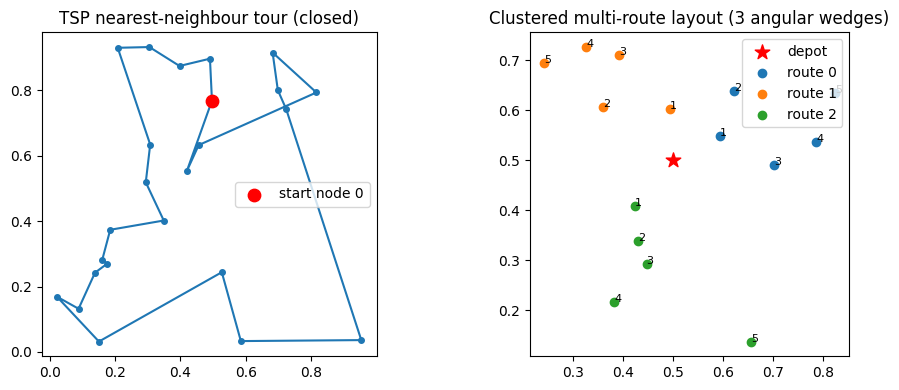

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from rl4co.envs.routing import TSPGenerator
from rl4co.utils.pe import (
    AbsolutePE, SinusoidalPE, RotaryPE, RelativePE, ALiBiBias,
    DACTCyclicPE, CycleFormerPE,
    build_route_graph, LaplacianPE, RandomWalkSE, ShortestPathBias,
    InRoutePE, CrossRoutePE, HierarchicalPE,
    get_positional_encoding,
)

torch.manual_seed(0)
np.random.seed(0)


def cos_sim(P: torch.Tensor, eps: float = 1e-9) -> torch.Tensor:
    """Row-wise cosine-similarity matrix of a [L, D] embedding (zero-norm rows -> 0)."""
    n = P.norm(dim=-1, keepdim=True).clamp_min(eps)
    Pn = P / n
    return Pn @ Pn.transpose(-1, -2)


def nearest_neighbour_tour(coords: torch.Tensor, start: int = 0):
    """Greedy NN tour over [N, 2] coords; returns (closed_route[N+1], route_coords[N+1, 2])."""
    n = coords.shape[0]
    unvisited = set(range(n))
    route = [start]
    unvisited.remove(start)
    while unvisited:
        last = route[-1]
        nxt = min(unvisited, key=lambda j: torch.dist(coords[last], coords[j]).item())
        route.append(nxt)
        unvisited.remove(nxt)
    route.append(start)  # close the tour
    route_t = torch.tensor(route)
    return route_t, coords[route_t]


# --- (1) TSP instance + NN tour ---
gen = TSPGenerator(num_loc=24)
td = gen(batch_size=[1])
tsp_coords = td['locs'][0]  # [24, 2]
tour, tour_coords = nearest_neighbour_tour(tsp_coords, start=0)
L = tour_coords.shape[0]  # = num_loc + 1 (closed)
print('TSP tour (closed):', tour.tolist())
print('route-ordered coords shape:', tuple(tour_coords.shape), '| start == end node:', tour[0].item() == tour[-1].item())

# --- (2) clustered multi-route layout: depot + 3 angular wedges ---
depot_xy = torch.tensor([0.5, 0.5])
n_routes = 3
per_route = 5
centers = torch.tensor([0.4, 2.4, 4.4])  # wedge center angles (radians), well separated
customers = [depot_xy.clone()]  # node 0 = depot
route_node_ids = []
for r in range(n_routes):
    ids = []
    angs = centers[r] + 0.35 * torch.randn(per_route)
    radii = torch.linspace(0.12, 0.34, per_route) + 0.02 * torch.randn(per_route)
    for a, rad in zip(angs, radii):
        xy = depot_xy + rad * torch.tensor([torch.cos(a), torch.sin(a)])
        ids.append(len(customers))
        customers.append(xy)
    route_node_ids.append(ids)
node_xy = torch.stack(customers)  # [N, 2]
N = node_xy.shape[0]

# routes as index lists, closed through the depot, then padded with depot index 0
routes = [[0] + ids + [0] for ids in route_node_ids]
Lr = max(len(r) for r in routes)
routes_tensor = torch.zeros(n_routes, Lr, dtype=torch.long)
for i, r in enumerate(routes):
    routes_tensor[i, : len(r)] = torch.tensor(r)
# build_route_graph treats a 2-D input as [B, Lr]; pass [1, R, Lr] so all route rows union into one graph
adj = build_route_graph(routes_tensor[None], num_nodes=N)  # [1, N, N]
print('multi-route: N =', N, '| adjacency symmetric:', bool(torch.allclose(adj, adj.transpose(-1, -2))),
      '| 0/1 entries:', bool(((adj == 0) | (adj == 1)).all()))

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(tour_coords[:, 0], tour_coords[:, 1], '-o', ms=4)
axs[0].scatter(tsp_coords[0, 0], tsp_coords[0, 1], c='red', s=80, zorder=5, label='start node 0')
axs[0].set_title('TSP nearest-neighbour tour (closed)'); axs[0].legend(); axs[0].set_aspect('equal')
colors = ['tab:blue', 'tab:orange', 'tab:green']
axs[1].scatter(*depot_xy, c='red', s=120, marker='*', zorder=5, label='depot')
for r, ids in enumerate(route_node_ids):
    pts = node_xy[ids]
    axs[1].scatter(pts[:, 0], pts[:, 1], c=colors[r], label=f'route {r}')
    for k, j in enumerate(ids):
        axs[1].annotate(str(k + 1), node_xy[j], fontsize=8)
axs[1].set_title('Clustered multi-route layout (3 angular wedges)'); axs[1].legend(); axs[1].set_aspect('equal')
plt.tight_layout(); plt.show()

## 1. Index-based / NLP-style PEs — `SinusoidalPE`, `AbsolutePE`

These are the classic Transformer encodings: a fixed sinusoid of the integer index, or a
learnable lookup table. The one-line usage:

```python
sin = get_positional_encoding('SIN', embed_dim=32)
pe  = sin(torch.arange(L))          # -> [L, 32]
```

Below: the PE matrix as a heatmap, and the position–position cosine-similarity matrix.
Similarity decays monotonically with `|i - j|`, so **the two ends of the tour (the same
physical depot node) get *minimal* similarity** — D2 fails. And because the x-axis is the
discrete index, equal index steps do not correspond to equal travel-distance steps along the
tour — D1 fails. The right-most panel makes the D1 point concrete: cumulative travel distance
is a very non-linear function of the index.

SIN -> (25, 32) | APE -> (25, 32)


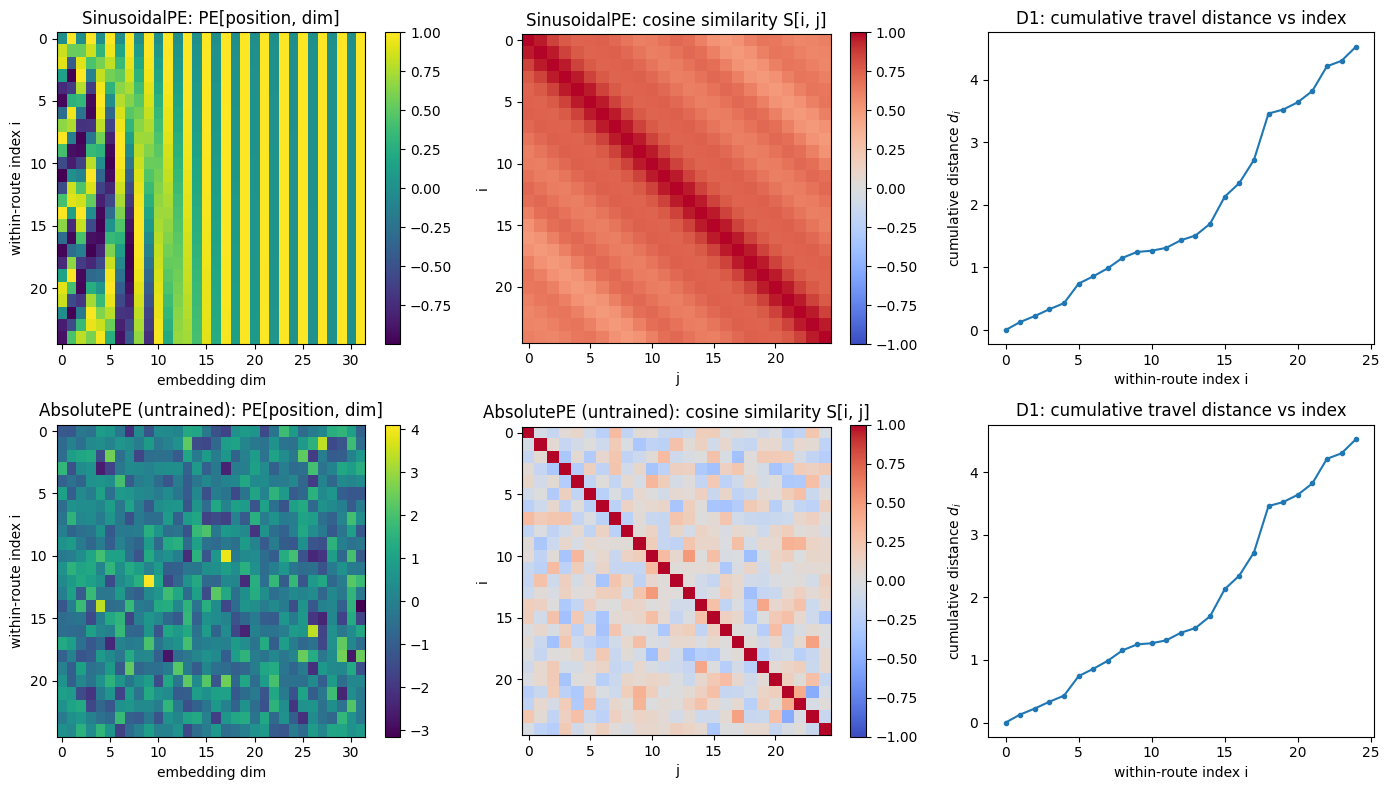

SinusoidalPE cosine similarity between the two depot endpoints (i=0 vs i=L-1): 0.621  ->  far from 1.0, i.e. D2 (circularity) is not satisfied.


In [2]:
sin = get_positional_encoding('SIN', embed_dim=32)
torch.manual_seed(0)
ape = get_positional_encoding('APE', embed_dim=32, max_len=L).eval()  # untrained: random init
positions = torch.arange(L)
pe_sin = sin(positions)            # [L, 32]
pe_ape = ape(positions).detach()   # [L, 32]
print('SIN ->', tuple(pe_sin.shape), '| APE ->', tuple(pe_ape.shape))

seg = torch.linalg.norm(tour_coords[1:] - tour_coords[:-1], dim=-1)
cumdist = torch.cat([torch.zeros(1), torch.cumsum(seg, 0)])  # d_i along the NN tour

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
for row, (name, P) in enumerate([('SinusoidalPE', pe_sin), ('AbsolutePE (untrained)', pe_ape)]):
    im0 = axs[row, 0].imshow(P, aspect='auto', cmap='viridis')
    axs[row, 0].set_title(f'{name}: PE[position, dim]'); axs[row, 0].set_xlabel('embedding dim'); axs[row, 0].set_ylabel('within-route index i')
    fig.colorbar(im0, ax=axs[row, 0])
    im1 = axs[row, 1].imshow(cos_sim(P), cmap='coolwarm', vmin=-1, vmax=1)
    axs[row, 1].set_title(f'{name}: cosine similarity S[i, j]'); axs[row, 1].set_xlabel('j'); axs[row, 1].set_ylabel('i')
    fig.colorbar(im1, ax=axs[row, 1])
    axs[row, 2].plot(positions, cumdist, '-o', ms=3)
    axs[row, 2].set_title('D1: cumulative travel distance vs index'); axs[row, 2].set_xlabel('within-route index i'); axs[row, 2].set_ylabel('cumulative distance $d_i$')
plt.tight_layout(); plt.show()

end_sim = cos_sim(pe_sin)[0, -1].item()
print(f'SinusoidalPE cosine similarity between the two depot endpoints (i=0 vs i=L-1): {end_sim:.3f}'
      '  ->  far from 1.0, i.e. D2 (circularity) is not satisfied.')

## 2. Cyclic PEs — `DACTCyclicPE`, `CycleFormerPE` (D2 partially recovered)

These index-based encodings are made *periodic* in the within-route position: `CycleFormerPE`
computes its sinusoid on `i mod L`, and `DACTCyclicPE` looks up a Gray code of `i mod L` and
projects it linearly to `D`. So they recover the topological half of D2 — `PE(i) = PE(i + L)` —
but they are still purely index-based, so D1 and D3 are not addressed.

For `CycleFormerPE` the wrap is exact; we check it with `torch.allclose`. For `DACTCyclicPE`
the Gray code is *not* bit-wise circular when `L` is not a power of two, and the untrained
linear projection makes endpoint-neighbour similarity arbitrary — so we visualize its
(block-)circulant structure on a **power-of-two** route length and otherwise only claim
"periodic indexing", not guaranteed adjacent-endpoint similarity.

CycleFormerPE: max |PE(i) - PE(i+L)| = 0.00e+00  ->  exact wrap-around (D2 topological).
DACTCyclicPE (L=16): max |PE(i) - PE(i+L)| = 0.00e+00  ->  periodic in i mod L.


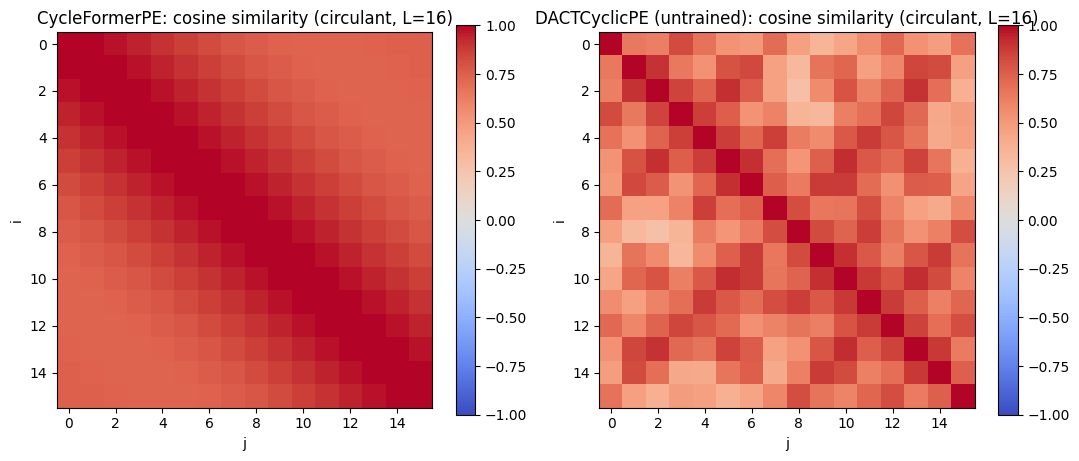

In [3]:
cyc = get_positional_encoding('CycleFormer', embed_dim=32)
# exact wrap-around for CycleFormer:
idx = torch.arange(L)
wrap_diff = (cyc(idx, seq_len=L) - cyc(idx + L, seq_len=L)).abs().max().item()
assert wrap_diff < 1e-5, wrap_diff
print(f'CycleFormerPE: max |PE(i) - PE(i+L)| = {wrap_diff:.2e}  ->  exact wrap-around (D2 topological).')

L_pow2 = 16
torch.manual_seed(0)
dact = get_positional_encoding('DACT', embed_dim=32, max_len=L_pow2)
idx_p = torch.arange(L_pow2)
pe_cyc = cyc(torch.arange(L_pow2), seq_len=L_pow2)
pe_dact = dact(idx_p, seq_len=L_pow2).detach()
dact_wrap = (dact(idx_p, seq_len=L_pow2) - dact(idx_p + L_pow2, seq_len=L_pow2)).abs().max().item()
print(f'DACTCyclicPE (L={L_pow2}): max |PE(i) - PE(i+L)| = {dact_wrap:.2e}  ->  periodic in i mod L.')

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, P) in zip(axs, [('CycleFormerPE', pe_cyc), ('DACTCyclicPE (untrained)', pe_dact)]):
    im = ax.imshow(cos_sim(P), cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_title(f'{name}: cosine similarity (circulant, L={L_pow2})'); ax.set_xlabel('j'); ax.set_ylabel('i')
    fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## 3. Attention-bias / rotation PEs — `RelativePE`, `ALiBiBias`, `RotaryPE`

These do not produce a per-node vector; they modify the *attention logits* by a function of
the index offset `i - j`:

- `RelativePE` adds a learnable bias `b_{clip(i-j, -W, W)}` (a banded Toeplitz matrix);
- `ALiBiBias` subtracts `m_h · |i - j|` with a fixed per-head slope `m_h`;
- `RotaryPE` rotates queries/keys so that `q_i · k_j` depends only on `i - j` (Toeplitz logits).

They inject *relative order* into attention, not geometry — none of them satisfies D1 or D3,
and they only weakly address D2. The bias/logit matrices below are Toeplitz (constant along
diagonals); we `assert` it for the RoPE logits.

RoPE logit matrix is Toeplitz (q_i . k_j depends only on i - j).


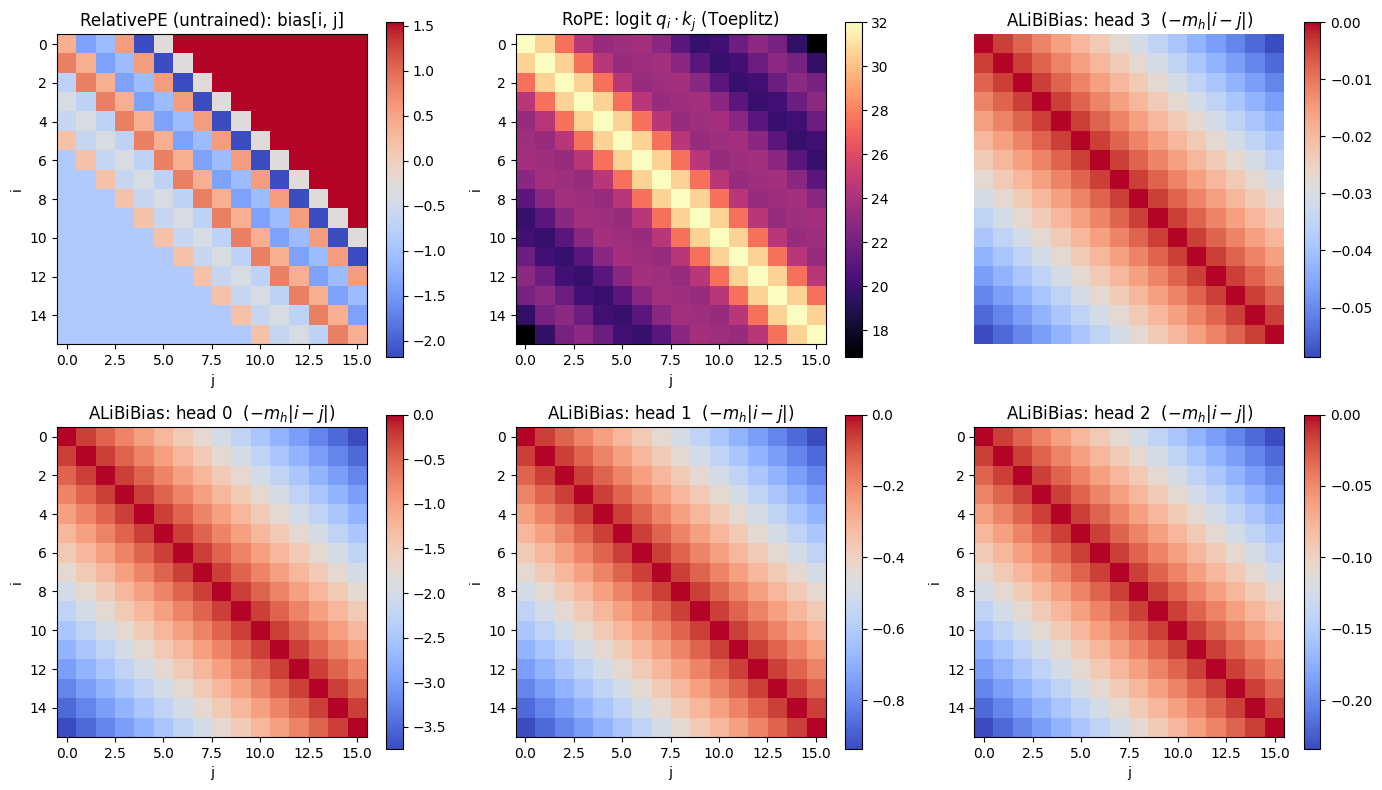

In [4]:
seq_len = 16
torch.manual_seed(0)
rpe = get_positional_encoding('RPE', window=6)        # untrained learnable bias
rpe_bias = rpe(seq_len).detach()                      # [L, L]
alibi = get_positional_encoding('ALiBi', num_heads=4)
alibi_bias = alibi(seq_len)                            # [num_heads, L, L]
rope = get_positional_encoding('RoPE', embed_dim=32)
q = k = torch.ones(1, seq_len, 32)
q_rot, k_rot = rope.rotate_queries_keys(q.clone(), k.clone(), torch.arange(seq_len)[None])
rope_logits = (q_rot @ k_rot.transpose(-1, -2))[0]     # [L, L]
# Toeplitz check: each diagonal is constant
for off in range(seq_len):
    d = torch.diagonal(rope_logits, offset=off)
    assert torch.allclose(d, d[0].expand_as(d), atol=1e-4)
print('RoPE logit matrix is Toeplitz (q_i . k_j depends only on i - j).')

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
im = axs[0, 0].imshow(rpe_bias, cmap='coolwarm'); axs[0, 0].set_title('RelativePE (untrained): bias[i, j]'); fig.colorbar(im, ax=axs[0, 0])
axs[0, 0].set_xlabel('j'); axs[0, 0].set_ylabel('i')
im = axs[0, 1].imshow(rope_logits, cmap='magma'); axs[0, 1].set_title('RoPE: logit $q_i\\cdot k_j$ (Toeplitz)'); fig.colorbar(im, ax=axs[0, 1])
axs[0, 1].set_xlabel('j'); axs[0, 1].set_ylabel('i')
axs[0, 2].axis('off')
for h in range(4):
    ax = axs[1, h % 3] if h < 3 else axs[0, 2]
    im = ax.imshow(alibi_bias[h], cmap='coolwarm'); ax.set_title(f'ALiBiBias: head {h}  $(-m_h|i-j|)$'); fig.colorbar(im, ax=ax)
    ax.set_xlabel('j'); ax.set_ylabel('i')
plt.tight_layout(); plt.show()

## 4. Graph-transformer PEs — `LaplacianPE`, `RandomWalkSE`, `ShortestPathBias`

These operate on the **route graph** (`build_route_graph`: depot + route arcs):

- `LaplacianPE` / `RandomWalkSE` give a per-node vector derived from the graph spectrum /
  random-walk structure. Nodes in the same route get similar embeddings, so they **partially**
  recover D3 (hierarchy) — but they ignore within-route *travel distance* (D1) and tour
  *circularity* (D2).
- `ShortestPathBias` is a pairwise attention bias indexed by graph shortest-path distance
  `spd(v_i, v_j)`. On the route graph the shortest-path distance grows along a route, so it is
  best described as a **D1-partial** pairwise distance bias (graph-distance, not Euclidean) —
  it is not a hierarchy signal and does not address D2/D3.

All of these have random / learnable parameters; we call `.eval()` and seed before
instantiating, and show the *structure*, not learned values.

LaplacianPE -> (16, 16) | RandomWalkSE -> (16, 16) | ShortestPathBias -> (16, 16)


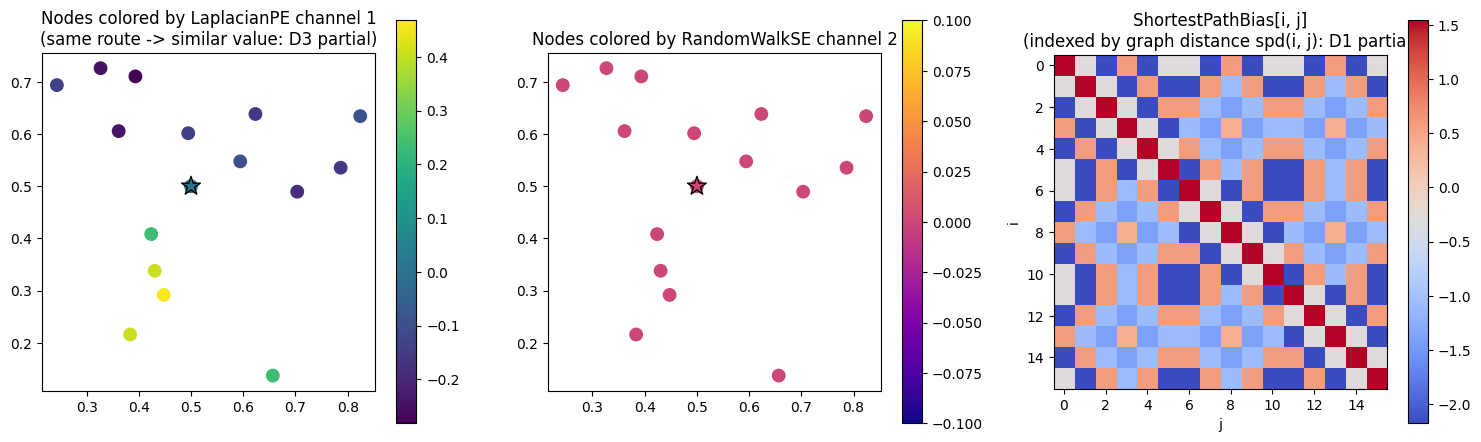

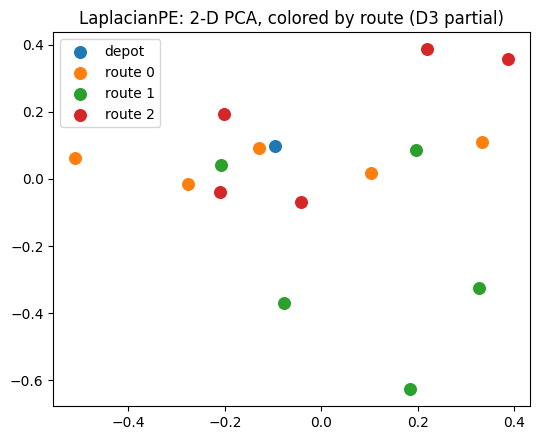

In [5]:
emb = 16
torch.manual_seed(0)
lap = LaplacianPE(embed_dim=emb, k=8).eval()
rwse = RandomWalkSE(embed_dim=emb, k=8).eval()
torch.manual_seed(0)
spd = ShortestPathBias(max_spd=8).eval()

pe_lap = lap(adj=adj)[0].detach()    # [N, emb]
pe_rwse = rwse(adj=adj)[0].detach()  # [N, emb]
spd_bias = spd(adj=adj)[0].detach()  # [N, N]
print('LaplacianPE ->', tuple(pe_lap.shape), '| RandomWalkSE ->', tuple(pe_rwse.shape), '| ShortestPathBias ->', tuple(spd_bias.shape))

route_id = torch.zeros(N, dtype=torch.long)  # 0 = depot; routes numbered 1..n_routes
for r, ids in enumerate(route_node_ids):
    for j in ids:
        route_id[j] = r + 1

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
sc = axs[0].scatter(node_xy[:, 0], node_xy[:, 1], c=pe_lap[:, 1], cmap='viridis', s=80)
axs[0].scatter(*depot_xy, marker='*', s=200, edgecolor='k', facecolor='none')
axs[0].set_title('Nodes colored by LaplacianPE channel 1\n(same route -> similar value: D3 partial)'); axs[0].set_aspect('equal'); fig.colorbar(sc, ax=axs[0])
sc = axs[1].scatter(node_xy[:, 0], node_xy[:, 1], c=pe_rwse[:, 2], cmap='plasma', s=80)
axs[1].scatter(*depot_xy, marker='*', s=200, edgecolor='k', facecolor='none')
axs[1].set_title('Nodes colored by RandomWalkSE channel 2'); axs[1].set_aspect('equal'); fig.colorbar(sc, ax=axs[1])
im = axs[2].imshow(spd_bias, cmap='coolwarm'); axs[2].set_title('ShortestPathBias[i, j]\n(indexed by graph distance spd(i, j): D1 partial)'); fig.colorbar(im, ax=axs[2])
axs[2].set_xlabel('j'); axs[2].set_ylabel('i')
plt.tight_layout(); plt.show()

# A 2-D PCA projection of the LaplacianPE, colored by route id (no sklearn):
X = pe_lap - pe_lap.mean(0, keepdim=True)
_, _, V = torch.pca_lowrank(X, q=2)
proj = X @ V[:, :2]
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for r in range(n_routes + 1):
    m = route_id == r
    ax.scatter(proj[m, 0], proj[m, 1], label=('depot' if r == 0 else f'route {r-1}'), s=70)
ax.set_title('LaplacianPE: 2-D PCA, colored by route (D3 partial)'); ax.legend(); plt.tight_layout(); plt.show()

## 5. Proposed in-route PE — `InRoutePE` (D1 + D2)

`InRoutePE` is *distance-indexed*: for a closed route it uses the cumulative travel distance
`d_i = Σ ||x_{v_j} - x_{v_{j-1}}||`, rescaled to one period `d̂_i = 2π d_i / d_L`, and a
multi-frequency sinusoid of `d̂_i`. Two variants:

- `direction_aware=False` (CVRP / TSP): cosine-only, **invariant to reversing the route**;
- `direction_aware=True` (VRPTW / PDTSP): sin/cos pairs, **distinguishes a route from its reversal** (the cosine half is unchanged, the sine half is negated).

(Implementation note from `reports/01.positional-encodings.md`: `InRoutePE` uses integer
harmonics `ω_k = k+1`, because the paper's geometric schedule is inconsistent with its own
circularity / reversal claims; the symmetry checks below therefore hold up to a small float32
`atol ≈ 1e-4`.)

Left: each output channel plotted against **cumulative distance** is a smooth sinusoid; against
the **index** it is not — that is D1. We also check `IPE(coords)[0] ≈ IPE(coords)[-1]` for the
closed tour (D2 topological), and the reversal (in)variance of the two variants.

InRoutePE -> (25, 32)
max |IPE(v_1) - IPE(v_L)|:  direction-invariant 0.00e+00  |  direction-aware 5.31e-06  (~1e-4 float32 tol)
direction-invariant: max |IPE - reverse(IPE)| = 1.70e-05  ->  reversal-invariant
direction-aware:     max |IPE - reverse(IPE)| = 2.00e+00  ->  NOT reversal-invariant
  ... cosine half (odd channels) unchanged: 7.39e-06
  ... sine half (even channels) negated:    7.44e-06


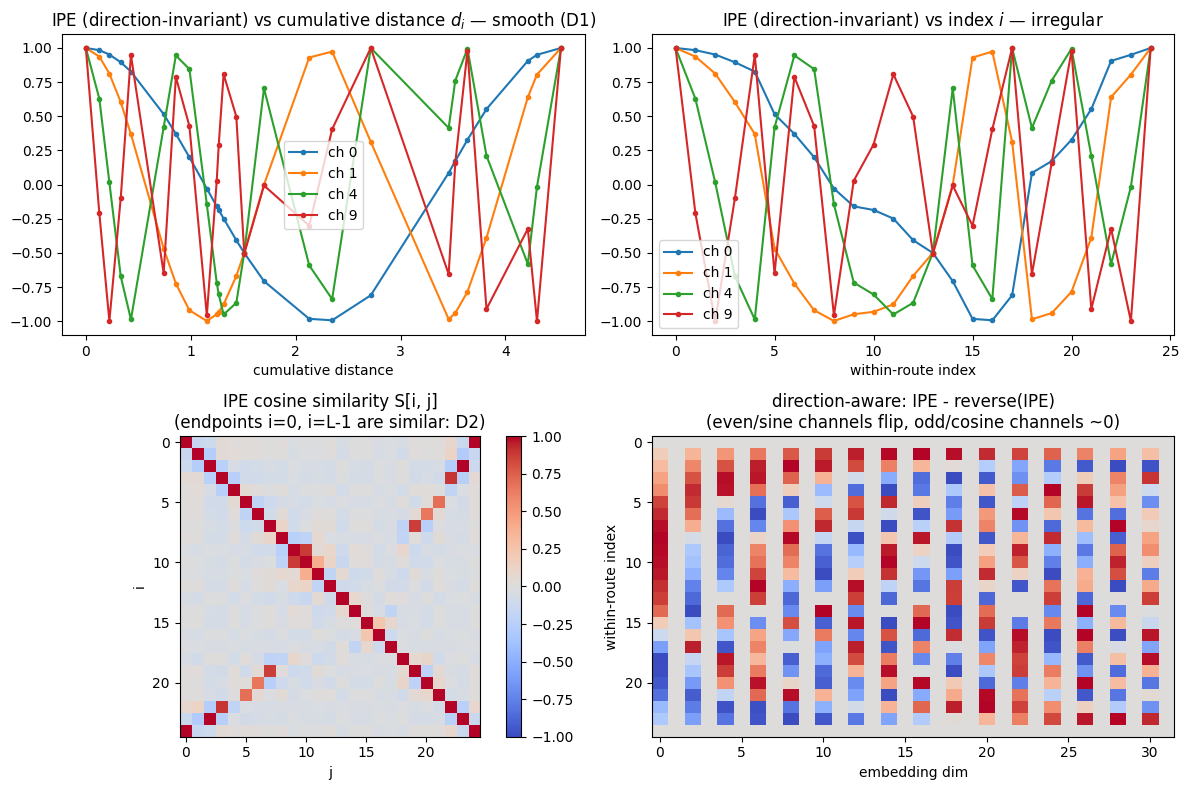

In [6]:
ipe_inv = InRoutePE(embed_dim=32, direction_aware=False)
ipe_dir = InRoutePE(embed_dim=32, direction_aware=True)
enc_inv = ipe_inv(tour_coords)   # [L, 32]
enc_dir = ipe_dir(tour_coords)   # [L, 32]
print('InRoutePE ->', tuple(enc_inv.shape))

# D2 topological: closed-tour endpoints coincide
d_end_inv = (enc_inv[0] - enc_inv[-1]).abs().max().item()
d_end_dir = (enc_dir[0] - enc_dir[-1]).abs().max().item()
print(f'max |IPE(v_1) - IPE(v_L)|:  direction-invariant {d_end_inv:.2e}  |  direction-aware {d_end_dir:.2e}  (~1e-4 float32 tol)')
assert d_end_inv < 1e-3 and d_end_dir < 1e-3

# Reversal behaviour
rev_coords = tour_coords.flip(0)
enc_inv_rev = ipe_inv(rev_coords).flip(0)
enc_dir_rev = ipe_dir(rev_coords).flip(0)
print(f'direction-invariant: max |IPE - reverse(IPE)| = {(enc_inv - enc_inv_rev).abs().max().item():.2e}  ->  reversal-invariant')
print(f'direction-aware:     max |IPE - reverse(IPE)| = {(enc_dir - enc_dir_rev).abs().max().item():.2e}  ->  NOT reversal-invariant')
print(f'  ... cosine half (odd channels) unchanged: {(enc_dir[:, 1::2] - enc_dir_rev[:, 1::2]).abs().max().item():.2e}')
print(f'  ... sine half (even channels) negated:    {(enc_dir[:, 0::2] + enc_dir_rev[:, 0::2]).abs().max().item():.2e}')
assert torch.allclose(enc_inv, enc_inv_rev, atol=1e-3)
assert not torch.allclose(enc_dir, enc_dir_rev, atol=1e-2)

chans = [0, 1, 4, 9]
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for c in chans:
    axs[0, 0].plot(cumdist, enc_inv[:, c], '-o', ms=3, label=f'ch {c}')
    axs[0, 1].plot(positions, enc_inv[:, c], '-o', ms=3, label=f'ch {c}')
axs[0, 0].set_title('IPE (direction-invariant) vs cumulative distance $d_i$ — smooth (D1)'); axs[0, 0].set_xlabel('cumulative distance'); axs[0, 0].legend()
axs[0, 1].set_title('IPE (direction-invariant) vs index $i$ — irregular'); axs[0, 1].set_xlabel('within-route index'); axs[0, 1].legend()
im = axs[1, 0].imshow(cos_sim(enc_inv), cmap='coolwarm', vmin=-1, vmax=1)
axs[1, 0].set_title('IPE cosine similarity S[i, j]\n(endpoints i=0, i=L-1 are similar: D2)'); fig.colorbar(im, ax=axs[1, 0]); axs[1, 0].set_xlabel('j'); axs[1, 0].set_ylabel('i')
axs[1, 1].imshow((enc_dir - enc_dir_rev), aspect='auto', cmap='coolwarm')
axs[1, 1].set_title('direction-aware: IPE - reverse(IPE)\n(even/sine channels flip, odd/cosine channels ~0)'); axs[1, 1].set_xlabel('embedding dim'); axs[1, 1].set_ylabel('within-route index')
plt.tight_layout(); plt.show()

## 6. Proposed cross-route PE & fusion — `CrossRoutePE`, `HierarchicalPE` (D3, full picture)

`CrossRoutePE` encodes the **depot-anchored polar angle** `θ_v = atan2(y_v - y_0, x_v - x_0)`
with a low-frequency sinusoidal map (`ω'_k = 2^k`, `K=4` bands, zero-padded to `D`). Because
near-optimal routes occupy roughly disjoint angular sectors around the depot, two nodes at the
*same within-route index but in different routes* land at different angles and therefore get
different `XPE` — that is D3.

`HierarchicalPE` is the per-node fusion input `[IPE(v) ‖ XPE(v)]` (the paper then concatenates
the raw coordinate and applies a shared feed-forward layer — that projection is outside the
scope of `pe.py`). Its output width is `2 · embed_dim`.

Below: customers colored by `θ_v` and by an `XPE` channel; a polar plot of `θ_v` per route;
the equal-index / different-route separation shown numerically; and a 2-D PCA of the
per-route `HierarchicalPE`, colored by route and annotated by within-route order — clusters
per route (D3) with intra-cluster ordering by distance (D1).

CrossRoutePE -> (16, 16) | zero-padded beyond 2K=8: True
within-route index 1: pairwise ||XPE_a - XPE_b|| across routes in [3.064, 3.269]  (> 0 => D3 separates them)
within-route index 2: pairwise ||XPE_a - XPE_b|| across routes in [2.569, 3.146]  (> 0 => D3 separates them)
within-route index 3: pairwise ||XPE_a - XPE_b|| across routes in [2.963, 3.468]  (> 0 => D3 separates them)
within-route index 4: pairwise ||XPE_a - XPE_b|| across routes in [3.455, 3.478]  (> 0 => D3 separates them)
within-route index 5: pairwise ||XPE_a - XPE_b|| across routes in [2.447, 3.453]  (> 0 => D3 separates them)


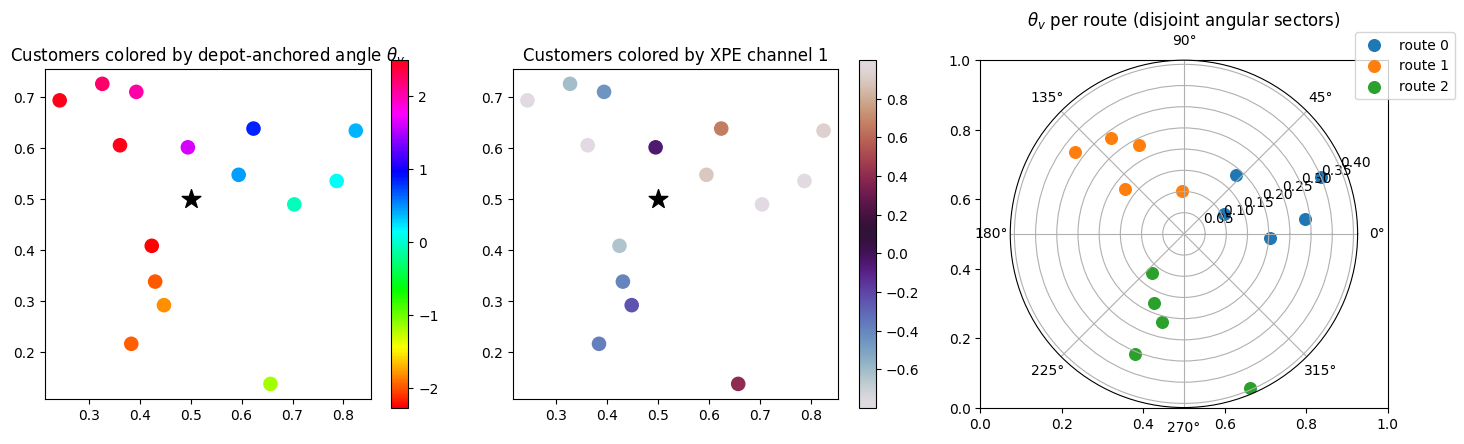

HierarchicalPE per-node width: 32 (= 2 * embed_dim = 32 )


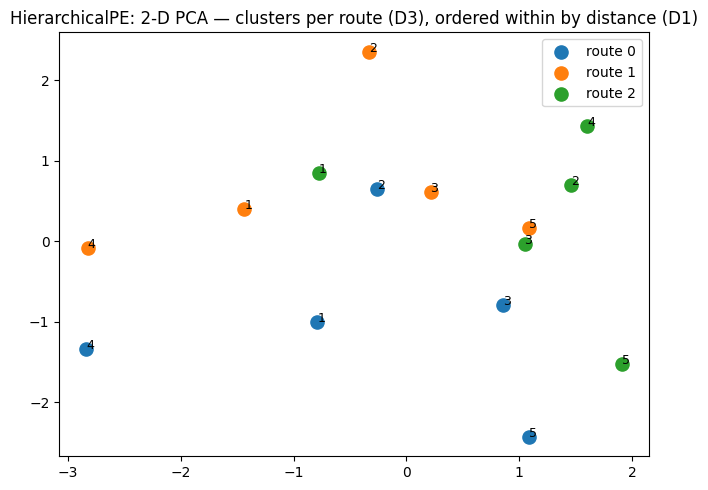

In [7]:
emb = 16
xpe = CrossRoutePE(embed_dim=emb, k=4)
hier = HierarchicalPE(embed_dim=emb, direction_aware=False, xpe_k=4)

rel = node_xy - depot_xy
theta = torch.atan2(rel[:, 1], rel[:, 0])  # [N]
xpe_all = xpe(node_xy, depot_xy)           # [N, emb]
print('CrossRoutePE ->', tuple(xpe_all.shape), '| zero-padded beyond 2K=8:', bool((xpe_all[:, 8:] == 0).all()))

# equal within-route index, different routes -> different XPE
for kk in range(1, per_route + 1):
    ids_at_k = [route_node_ids[r][kk - 1] for r in range(n_routes)]
    sub = xpe_all[ids_at_k]
    pdist = torch.cdist(sub, sub)
    offdiag = pdist[~torch.eye(n_routes, dtype=torch.bool)]
    print(f'within-route index {kk}: pairwise ||XPE_a - XPE_b|| across routes in [{offdiag.min():.3f}, {offdiag.max():.3f}]  (> 0 => D3 separates them)')

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
sc = axs[0].scatter(node_xy[1:, 0], node_xy[1:, 1], c=theta[1:], cmap='hsv', s=90)
axs[0].scatter(*depot_xy, marker='*', s=200, c='k'); axs[0].set_title('Customers colored by depot-anchored angle $\\theta_v$'); axs[0].set_aspect('equal'); fig.colorbar(sc, ax=axs[0])
sc = axs[1].scatter(node_xy[1:, 0], node_xy[1:, 1], c=xpe_all[1:, 1], cmap='twilight', s=90)
axs[1].scatter(*depot_xy, marker='*', s=200, c='k'); axs[1].set_title('Customers colored by XPE channel 1'); axs[1].set_aspect('equal'); fig.colorbar(sc, ax=axs[1])
ax = plt.subplot(1, 3, 3, projection='polar')
for r, ids in enumerate(route_node_ids):
    ax.scatter(theta[ids], (node_xy[ids] - depot_xy).norm(dim=-1), label=f'route {r}', s=70)
ax.set_title('$\\theta_v$ per route (disjoint angular sectors)'); ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout(); plt.show()

# Per-route HierarchicalPE -> stack all customers -> 2-D PCA, colored by route, annotated by order
all_h, all_route, all_order = [], [], []
for r, ids in enumerate(route_node_ids):
    rc = torch.cat([depot_xy[None], node_xy[ids], depot_xy[None]])  # closed route coords
    h = hier(rc, depot_xy)  # [len(ids)+2, 2*emb]
    h = h[1:-1]             # drop the depot endpoints
    all_h.append(h); all_route += [r] * len(ids); all_order += list(range(1, len(ids) + 1))
H = torch.cat(all_h, 0)
print('HierarchicalPE per-node width:', H.shape[-1], '(= 2 * embed_dim =', 2 * emb, ')')
Hc = H - H.mean(0, keepdim=True)
_, _, V = torch.pca_lowrank(Hc, q=2)
projH = Hc @ V[:, :2]
all_route = torch.tensor(all_route)
fig, ax = plt.subplots(figsize=(6.5, 5))
for r in range(n_routes):
    m = all_route == r
    ax.scatter(projH[m, 0], projH[m, 1], label=f'route {r}', s=90, c=colors[r])
    for (x, y), o in zip(projH[m], [all_order[i] for i in range(len(all_order)) if all_route[i] == r]):
        ax.annotate(str(o), (x, y), fontsize=9)
ax.set_title('HierarchicalPE: 2-D PCA — clusters per route (D3), ordered within by distance (D1)'); ax.legend(); plt.tight_layout(); plt.show()

### Which desideratum does each PE illustrate?

Summary of what the visualizations above showed (consistent with the paper's `tab:desiderata`
✓ / ∼ / ✗ table):

| PE | D1 distance | D2 circularity | D3 hierarchy |
|---|:---:|:---:|:---:|
| `AbsolutePE`, `SinusoidalPE` | ✗ | ✗ | ✗ |
| `RotaryPE`, `RelativePE` | ✗ | ∼ | ✗ |
| `ALiBiBias` | ✗ | ✗ | ✗ |
| `DACTCyclicPE`, `CycleFormerPE` | ✗ | ✓ (topological) | ✗ |
| `LaplacianPE`, `RandomWalkSE` | ✗ | ✗ | ∼ |
| `ShortestPathBias` | ∼ (graph distance) | ✗ | ✗ |
| `InRoutePE` | ✓ | ✓ | ✗ |
| `CrossRoutePE` | ✗ | — | ✓ |
| `HierarchicalPE` (`IPE ‖ XPE`) | ✓ | ✓ | ✓ |

## Wrap-up

All encodings above come from a single module, [`rl4co/utils/pe.py`](../../rl4co/utils/pe.py),
and can be instantiated either directly or via `get_positional_encoding(name, **kwargs)`. The
index-based and bias/rotation encodings are easy drop-ins but carry no geometry; the cyclic
ones add the topological half of D2; the graph encodings add a partial hierarchy signal; and
the proposed `InRoutePE` / `CrossRoutePE` / `HierarchicalPE` are built specifically around the
solution geometry (within-route travel distance and depot-anchored angle), giving D1 + D2 + D3.

See the paper's §3 (taxonomy / desiderata) and §4 (the proposed method) for the full story,
and the class docstrings in `pe.py` for the precise input/output contracts.